In [1]:
import numpy as np

import matplotlib.pyplot as plt                 # Manipular gráficas
from IPython.display import Image, display      # Mostrar animaciones

from EcuacionCalor import (
    primitiva_rect,
    FDM_HeatModel,
    generar_DIR, generar_ROB, generar_NEU,
    fdm2d, fdm2d_graph_mesh,
    GraphType
)

GUIA DE TRABAJOS PRACTICOS Nº 2
---

# MÉTODO DE DIFERENCIAS FINITAS 2D

## Ejercicio 1

Dada la siguiente ecuación diferencial en dos dimensiones que modela la transferencia de calor en
una placa:

$$
\rho c_p \frac{\partial T}{\partial t}
= k \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) - c ~T + G, \quad \forall ~x \in [x_1,x_2], \forall ~y \in [y_1,y_2]
$$

Resuelva los problemas propuestos en la siguiente tabla, donde se describen los valores de las
constantes del modelo y las condiciones de borde. Consideraciones a tener en cuenta:

* Analice los órdenes de aproximación al utilizar aproximaciones de 1er y 2do orden para las condiciones de borde.
* Analice los órdenes de aproximación al utilizar mallas uniformes y no uniformes.
* Implemente los siguientes esquemas temporales: Forward Euler, Backward Euler. Considerar siempre la condición inicial nula: $T(x,0)=0$.

### Ítem (e)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>e</td>
            <td>(0, 0)</td>
            <td>(3, 5)</td>
            <td>h=2, $\phi_\infty$=100</td>
            <td>T=50</td>
            <td>T=0</td>
            <td>T=25</td>
            <td>1</td>
            <td>2</td>
            <td>0</td>
            <td>$10 x^3$</td>
        </tr>
    </tbody>
</table>

In [2]:
xnode, icone, vert, bounds = primitiva_rect(x_scale=3.0, y_scale=5.0, x_subdiv=2, y_subdiv=2, plot=False)

Condiciones de contorno según el orden de `bounds`:

$F0 ~\{x_1 \leq x \leq x_2, y_1\} : ~h = 2, ~\phi_\infty = 100$ / Normal al sur (1)

$F1 ~\{x_2, y_1 \leq y \leq y_2\} : ~T = 25$

$F2 ~\{x_1 \leq x \leq x_2, y_2\} : ~T = 50$

$F3 ~\{x_1, y_1 \leq y \leq y_2\} : ~T = 0$

In [3]:
nnoodes = len(xnode)

# Fuente
G = 10.0 * np.pow(xnode[:,0], 3)

# Modelo inciso (e)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.full(nnoodes, 2.0),
    c = np.zeros(nnoodes),
    G = G,
    rho = 1.0,
    cp = 1.0,
    ts = 0,         # Explícito
    # ts = 1,       # Implícito
    # dt = 0.01,
    maxit = int(1E5),
    tol = 1E-6,
    PHI_n = np.zeros(nnoodes),
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F1 = generar_DIR(bounds[1], xnode, f_constante(25))
DIR_F2 = generar_DIR(bounds[2], xnode, f_constante(50))
DIR_F3 = generar_DIR(bounds[3], xnode, f_constante(0))

DIR = np.vstack((
    DIR_F1,
    DIR_F2,
    DIR_F3,
))

# Condiciones de contorno Robin
ROB_F0 = generar_ROB(bounds[0], xnode, f_constante(2.0), f_constante(100.0), 1)
ROB = np.vstack((
    ROB_F0,
))

PHI, Q = fdm2d(xnode, icone, DIR, None, ROB, model)

Explicit temporal scheme
dt = 0.0078125
Iter 100
Iter 200
Iter 300
Iter 400
Iter 500
Iter 600
Iter 700
Iter 800
Iter 900
Iter 1000
Stop on iter  1088


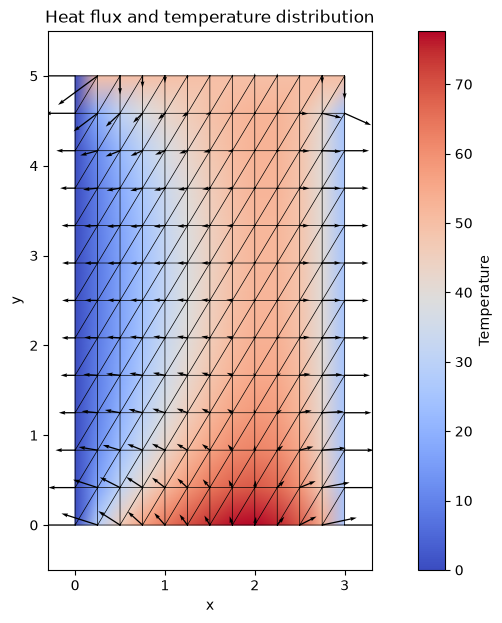

In [4]:
fdm2d_graph_mesh(xnode, icone, PHI[-1], Q[-1], graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.1);

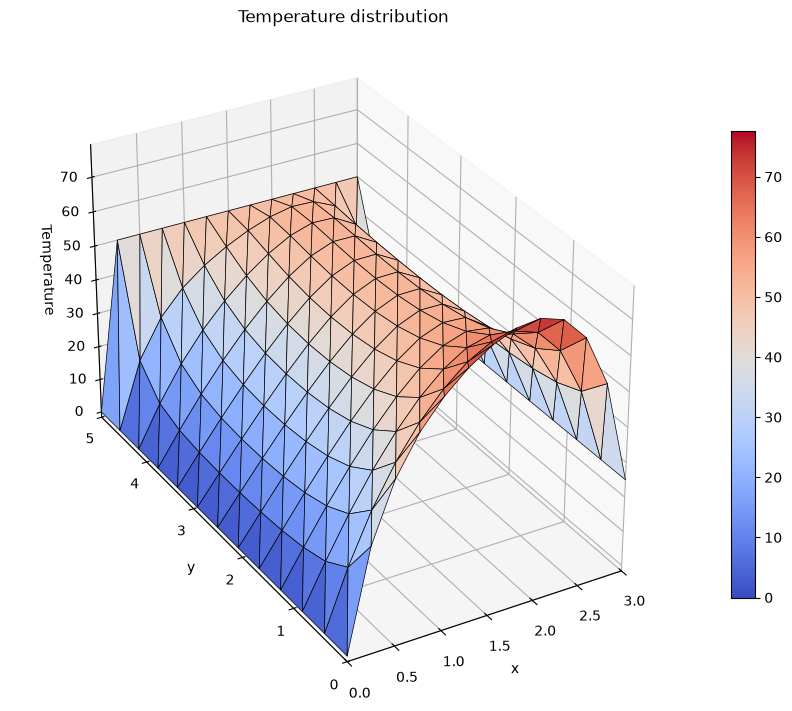

In [5]:
fdm2d_graph_mesh(xnode, icone, PHI[-1], Q[-1], graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=-120);

In [ ]:
filename = "GTP-MDF-2D_Ejercicio-1e.gif"
fig, anim = fdm2d_graph_mesh(xnode, icone, PHI, Q, delta_t = 0.0078125, graph=GraphType.TEMPERATURE, dimension=3, transient=True,
                             mesh=True, margin=0, fps=10, frames=50, azim=-120, save_path=filename)

plt.close()
# display(Image(filename=filename))

![](./GTP-MDF-2D_Ejercicio-1e.gif)

### Ítem (f)

<table>
    <thead>
        <tr>
            <th rowspan="1"></th>
            <th colspan="2">Extremos</th>
            <th colspan="4">Condiciones de borde</th>
            <th colspan="4">Constantes del modelo</th>
        </tr>
        <tr>
            <th>Ítem</th>
            <th>Inferior<br>Izquierda</th>
            <th>Superior<br>Derecha</th>
            <th>($x_1 < x < x_2, y_1$)</th>
            <th>($x_1 < x < x_2, y_2$)</th>
            <th>($x_1, y_1 < y < y_2$)</th>
            <th>($x_2, y_1 < y < y_2$)</th>
            <th>$\rho c_p$</th>
            <th>k</th>
            <th>c</th>
            <th>G</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>f</td>
            <td>(0, 0)</td>
            <td>(2, 2)</td>
            <td>T=0</td>
            <td>h=2, $\phi_\infty$=10</td>
            <td>h=2, $\phi_\infty$=10</td>
            <td>T=100</td>
            <td>2</td>
            <td>2</td>
            <td>2</td>
            <td>100</td>
        </tr>
    </tbody>
</table>

In [7]:
xnode, icone, vert, bounds = primitiva_rect(x_scale=2.0, y_scale=2.0, x_subdiv=2, y_subdiv=2, plot=False)

Condiciones de contorno según el orden de `bounds`:

$F0 ~\{x_1 \leq x \leq x_2, y_1\} : ~T = 0$

$F1 ~\{x_2, y_1 \leq y \leq y_2\} : ~T = 100$

$F2 ~\{x_1 \leq x \leq x_2, y_2\} : ~h = 2, ~\phi_\infty = 10$ / Normal al norte (3)

$F3 ~\{x_1, y_1 \leq y \leq y_2\} : ~h = 2, ~\phi_\infty = 10$ / Normal al oeste (4)

In [8]:
nnoodes = len(xnode)

# Modelo inciso (f)
model = FDM_HeatModel(
    nnodes = nnoodes,
    k = np.full(nnoodes, 2.0),
    c = np.full(nnoodes, 2.0),
    G = np.full(nnoodes, 100.0),
    rho = 1.0,
    cp = 2.0,
    ts = 1,         # Implícito
    dt = 0.01,
    maxit = int(1E5),
    tol = 1E-6,
    PHI_n = np.zeros(nnoodes),
)

def f_constante(a):
    return lambda x,y : (a)

# Condiciones de contorno Dirichlet
DIR_F0 = generar_DIR(bounds[0], xnode, f_constante(0.0))
DIR_F1 = generar_DIR(bounds[1], xnode, f_constante(100.0))

DIR = np.vstack((
    DIR_F0,
    DIR_F1,
))

# Condiciones de contorno Robin
ROB_F2 = generar_ROB(bounds[2], xnode, f_constante(2.0), f_constante(10.0), 3)
ROB_F3 = generar_ROB(bounds[3], xnode, f_constante(2.0), f_constante(10.0), 4)
ROB = np.vstack((
    ROB_F2,
    ROB_F3,
))

PHI, Q = fdm2d(xnode, icone, DIR, None, ROB, model)

Implicit temporal scheme
dt = 0.01
Iter 100
Iter 200
Iter 300
Iter 400
Iter 500
Iter 600
Iter 700
Iter 800
Iter 900
Iter 1000
Iter 1100
Iter 1200
Iter 1300
Iter 1400
Iter 1500
Iter 1600
Stop on iter  1683


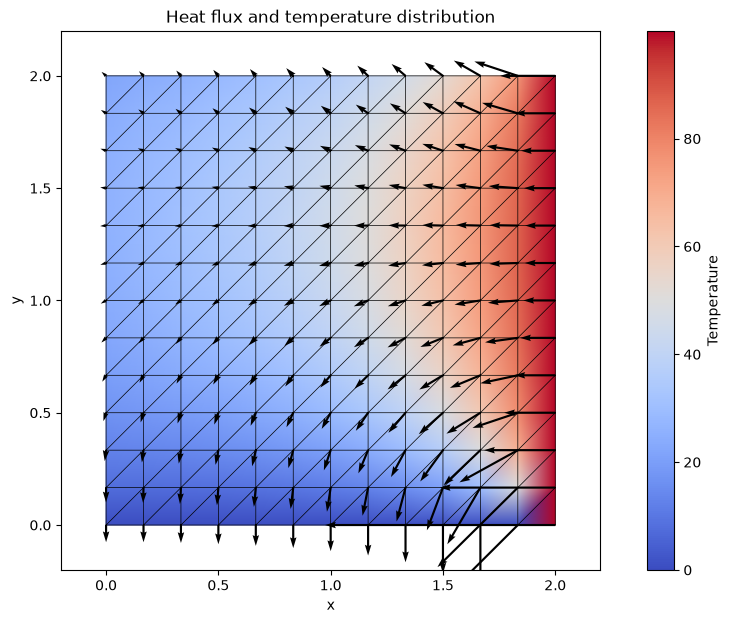

In [9]:
fdm2d_graph_mesh(xnode, icone, PHI[-1], Q[-1], graph=GraphType.HEAT_FLUX, dimension=2, transient=False, mesh=True, margin=0.1);

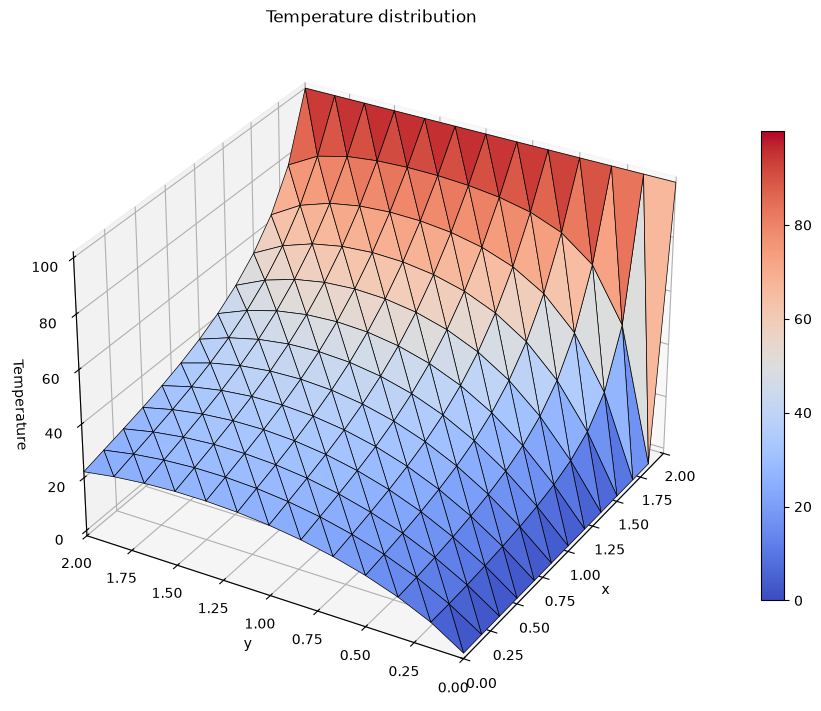

In [10]:
fdm2d_graph_mesh(xnode, icone, PHI[-1], Q[-1], graph=GraphType.TEMPERATURE, dimension=3, transient=False, mesh=True, margin=0, azim=-150);

In [ ]:
filename = "GTP-MDF-2D_Ejercicio-1f.gif"
fig, anim = fdm2d_graph_mesh(xnode, icone, PHI, Q, delta_t = model.dt, graph=GraphType.TEMPERATURE, dimension=3, transient=True,
                             mesh=True, margin=0, fps=10, frames=50, azim=-150, save_path=filename)

plt.close()
# display(Image(filename=filename))

![](./GTP-MDF-2D_Ejercicio-1f.gif)